In [2]:
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

df = pd.read_csv('./data/bbb.csv', sep=';')
df = df[df['Objects'].str.contains('_c0')]
df['Objects'] = df['Objects'].str.replace('_c0', '')
df_label = pd.read_csv('./data/bbb_label.csv', sep=' ', header=None)
# give a name to the columns 
df_label.columns = ['Objects', 'label']
# select only row with the same name as in the label file
df = df[df['Objects'].isin(df_label['Objects'])]
df = df.set_index('Objects')
df_label = df_label.set_index('Objects')
# add all in a single dataframe
df = df.join(df_label)
print(df.head())

                V        S        R        G        W1       W2       W3  \
Objects                                                                    
MOL_0001  747.125  482.581  1.54819  1.33424  1098.380  579.750  272.750   
MOL_0002  952.125  637.029  1.49463  1.58788  1294.120  597.500  262.625   
MOL_0004  549.625  368.758  1.49047  1.21149   798.000  324.500  105.500   
MOL_0009  595.750  414.276  1.43805  1.33090   898.375  406.875  210.125   
MOL_0012  448.500  316.026  1.41919  1.17786   692.250  323.000  145.625   

               W4      W5      W6  ...     L4LgS     DD1     DD2    DD3  \
Objects                            ...                                    
MOL_0001  106.375  48.875  13.875  ... -0.067867  61.750  32.500  15.75   
MOL_0002  104.625  54.875  29.750  ... -0.137969  92.875  37.500  20.25   
MOL_0004   35.875  15.500   6.625  ...  0.012077   0.000   0.000   0.00   
MOL_0009   98.000  51.625  25.125  ... -0.315401  30.500  20.125  11.50   
MOL_0012   63.000

In [6]:
X = df.drop('label', axis=1)
X = X.fillna(0)
y = df['label']
print(X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, \
                    test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(2103, 128)
(1682, 128) (421, 128)


In [8]:
CORRCUT = 0.95
# remove highly correlated features using the training set only
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), \
                                  k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > CORRCUT)]
X_train = X_train.drop(X_train[to_drop], axis=1)
X_test = X_test.drop(X_test[to_drop], axis=1)
print(X_train.shape) 
print(X_test.shape)

(1682, 69)
(421, 69)


In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Define the model
rf = RandomForestClassifier(random_state=42)

# 2. Define the grid of parameters you want to test
param_grid = {
    'n_estimators': range(10, 400, 10),
    'max_depth': list(range(5, 20, 5)) + [None]
}

# 3. Set up the Grid Search (cv=5 means 5-fold cross-validation)
grid_search = GridSearchCV(estimator=rf, \
                        param_grid=param_grid, \
                        cv=5, scoring='accuracy', \
                        n_jobs=-1)

# 4. Fit it to the data
grid_search.fit(X_train, y_train)

# 5. View the best results
print(f"Best Accuracy: {grid_search.best_score_}")
print(f"Best Parameters: {grid_search.best_params_}")

Best Accuracy: 0.8650575808958598
Best Parameters: {'max_depth': None, 'n_estimators': 220}


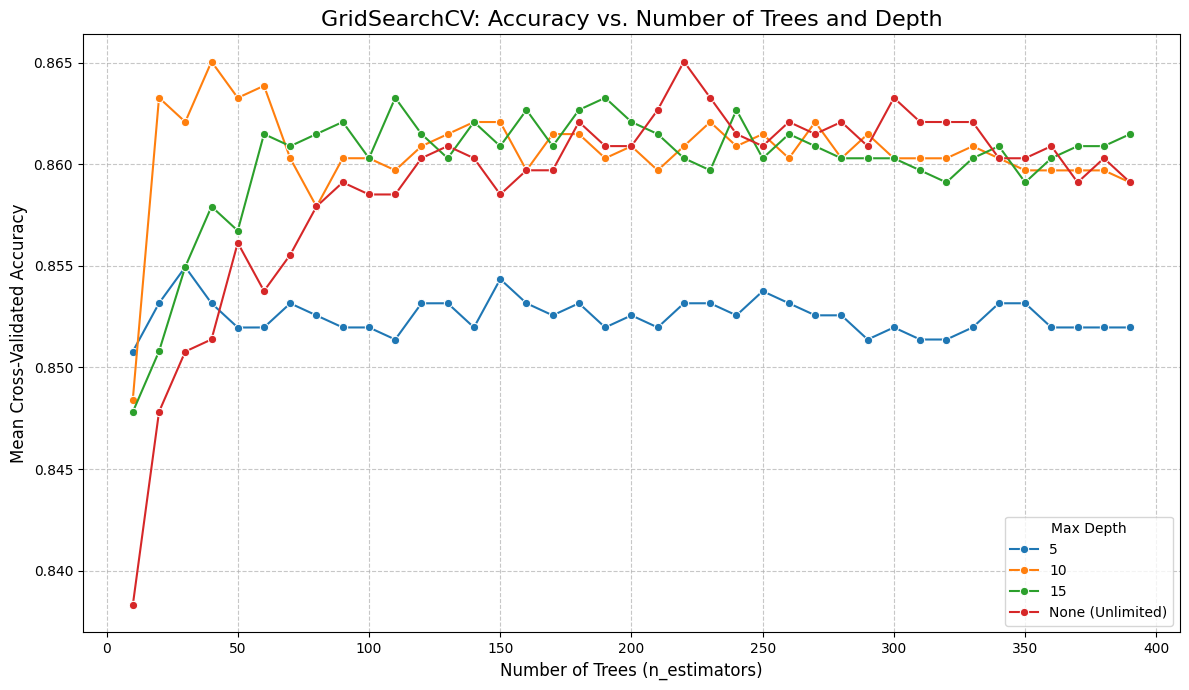

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract the results from GridSearchCV into a DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# 2. Keep only the columns we need and rename them to be readable
plot_df = results_df[['param_n_estimators', 'param_max_depth', 'mean_test_score']].copy()
plot_df = plot_df.rename(columns={
    'param_n_estimators': 'Number of Trees',
    'param_max_depth': 'Depth',
    'mean_test_score': 'Accuracy'
})

# 3. Handle the 'None' depth so Seaborn can group it in the legend properly
plot_df['Depth'] = plot_df['Depth'].fillna('None (Unlimited)')

# 4. Create the plot
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=plot_df, 
    x='Number of Trees', 
    y='Accuracy', 
    hue='Depth',   
    marker='o',    
    palette='tab10' 
)

# 5. Format the plot
plt.title('GridSearchCV: Accuracy vs. Number of Trees and Depth', fontsize=16)
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Mean Cross-Validated Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Max Depth')
plt.tight_layout()

# 6. Show the plot
plt.show()


In [ ]:

bestnumberoftrees = grid_search.best_params_['n_estimators']
bestdepth = grid_search.best_params_['max_depth']

rf = RandomForestClassifier(n_estimators=bestnumberoftrees, \
                            max_depth=bestdepth, \
                            random_state=42)
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

print("   Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("  Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("  Test Precision:", precision_score(y_test, y_pred_test))
print(" Train Precision:", precision_score(y_train, y_pred_train))
print("     Test Recall:", recall_score(y_test, y_pred_test))
print("    Train Recall:", recall_score(y_train, y_pred_train))

print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))
print("Train Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train))


  Test Accuracy: 0.836104513064133
 Train Accuracy: 1.0
  Test Precision: 0.8457300275482094
 Train Precision: 1.0
     Test Recall: 0.959375
    Train Recall: 1.0
Test Confusion Matrix:
[[ 45  56]
 [ 13 307]]
Train Confusion Matrix:
[[ 358    0]
 [   0 1324]]


In [15]:
from sklearn.model_selection import GridSearchCV

# 1. Define the model
rf = RandomForestClassifier(random_state=42)

# 2. Define the grid of parameters you want to test
param_grid = {
    'n_estimators': [100, 200, 300],        # Fewer options to save computation time
    'max_depth': [5, 10, 15],               # Hard limits on depth (removed 'None')
    'min_samples_split': [2, 10, 20],       # Minimum samples required to split a node
    'min_samples_leaf': [1, 5, 10]          # Minimum samples required at a leaf node
}

# 3. Set up the Grid Search (cv=5 means 5-fold cross-validation)
grid_search = GridSearchCV(estimator=rf, \
                        param_grid=param_grid, \
                        cv=5, scoring='accuracy', \
                        n_jobs=-1)

# 4. Fit it to the data
grid_search.fit(X_train, y_train)

# 5. View the best results
print(f"Best Accuracy: {grid_search.best_score_}")
print(f"Best Parameters: {grid_search.best_params_}")

Best Accuracy: 0.8620831567048184
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [16]:

bestnumberoftrees = grid_search.best_params_['n_estimators']
bestdepth = grid_search.best_params_['max_depth']

rf = RandomForestClassifier(n_estimators=bestnumberoftrees, \
                            max_depth=bestdepth, \
                            random_state=42)
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

print("   Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("  Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("  Test Precision:", precision_score(y_test, y_pred_test))
print(" Train Precision:", precision_score(y_train, y_pred_train))
print("     Test Recall:", recall_score(y_test, y_pred_test))
print("    Train Recall:", recall_score(y_train, y_pred_train))

print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))
print("Train Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train))


   Test Accuracy: 0.838479809976247
  Train Accuracy: 0.9916765755053508
  Test Precision: 0.8461538461538461
 Train Precision: 0.9895366218236173
     Test Recall: 0.9625
    Train Recall: 1.0
Test Confusion Matrix:
[[ 45  56]
 [ 12 308]]
Train Confusion Matrix:
[[ 344   14]
 [   0 1324]]


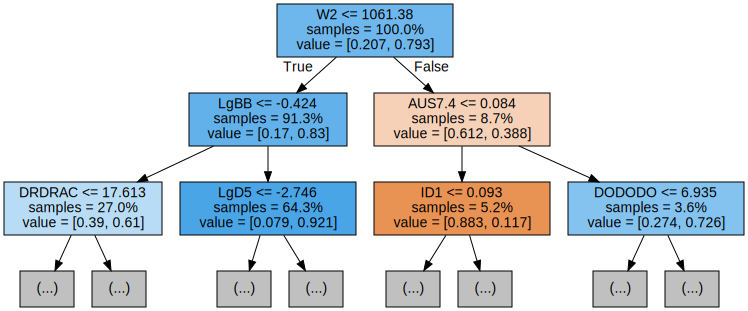

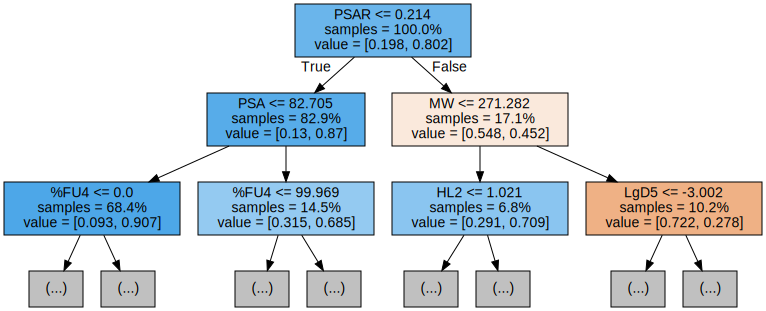

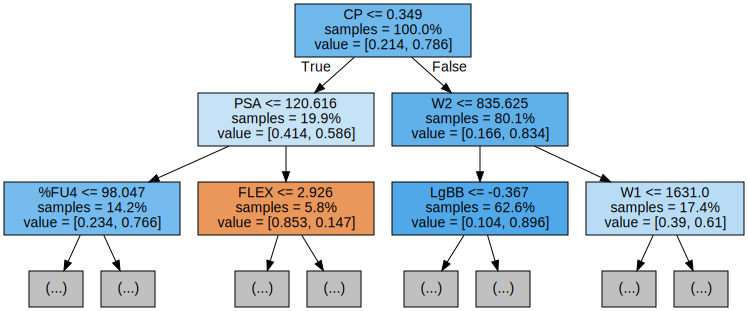

In [17]:
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

In [18]:
# 1. Add class_weight='balanced' to force the model to respect the minority class
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200, 300],        
    'max_depth': [5, 10, 15],               
    'min_samples_split': [2, 10, 20],       
    'min_samples_leaf': [1, 5, 10]          
}

# 2. Change scoring to 'f1' (or 'balanced_accuracy') to stop the model from taking the easy way out
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1',  # <--- Changed from 'accuracy'
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_test_pred = best_rf.predict(X_test)

In [20]:

bestnumberoftrees = grid_search.best_params_['n_estimators']
bestdepth = grid_search.best_params_['max_depth']

rf = RandomForestClassifier(n_estimators=bestnumberoftrees, \
                            max_depth=bestdepth, \
                            
                            random_state=42)
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

print("   Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("  Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("  Test Precision:", precision_score(y_test, y_pred_test))
print(" Train Precision:", precision_score(y_train, y_pred_train))
print("     Test Recall:", recall_score(y_test, y_pred_test))
print("    Train Recall:", recall_score(y_train, y_pred_train))

print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))
print("Train Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train))


   Test Accuracy: 0.838479809976247
  Train Accuracy: 0.9910820451843044
  Test Precision: 0.8461538461538461
 Train Precision: 0.9887976101568334
     Test Recall: 0.9625
    Train Recall: 1.0
Test Confusion Matrix:
[[ 45  56]
 [ 12 308]]
Train Confusion Matrix:
[[ 343   15]
 [   0 1324]]


In [21]:
# Instead of getting the final prediction, get the raw probabilities
y_pred_probs = best_rf.predict_proba(X_test)[:, 1]

# Set a stricter custom threshold (e.g., 0.70 instead of the default 0.50)
custom_threshold = 0.70
y_pred_custom = (y_pred_probs >= custom_threshold).astype(int)

# Check your new confusion matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_custom))

[[ 62  39]
 [ 36 284]]
